In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

CSV_INPUT = Path(r"C:\Users\david\Documents\TFG\train_dataset.csv") 

In [2]:
data = pd.read_csv(CSV_INPUT)
data

,video_id,stance_label,knee_start,knee_min,knee_Target,ankle_drag,ankle_min_dist,hip_tilt
0,flat_pinpoint_103_landmarks,0,168.74,138.30,152.53,25.0840,0.2729,1.0000
1,flat_pinpoint_107_landmarks,0,160.42,144.11,157.38,2.0281,1.4618,0.6861
2,flat_pinpoint_113_landmarks,0,162.51,106.18,140.36,28.2208,0.0728,0.5855
3,flat_pinpoint_115_landmarks,0,174.32,123.50,131.55,6.3603,0.1099,0.8439
4,flat_pinpoint_116_landmarks,0,156.98,137.55,140.96,17.1229,0.2096,0.6289
...,...,...,...,...,...,...,...,...
319,slice_platform_76_landmarks,1,173.95,130.06,143.88,4.5566,2.8044,0.4693
320,slice_platform_77_landmarks,1,164.73,126.63,138.50,1.7986,2.8344,0.5489
321,slice_platform_82_landmarks,1,161.63,128.45,141.59,3.5252,2.1181,0.4736
322,slice_platform_85_landmarks,1,179.99,137.06,142.16,7.2953,0.6506,0.6777


In [5]:
X = data.drop(['video_id', 'stance_label'], axis=1)
y = data['stance_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
    )

In [6]:
print(f"Datos divididos correctamente")
print(f"Entrenamos con {len(X_train)} videos")
print(f"Evaluamos con {len(X_test)} videos")

Datos divididos correctamente
Entrenamos con 259 videos
Evaluamos con 65 videos


In [7]:
X_test

,knee_start,knee_min,knee_Target,ankle_drag,ankle_min_dist,hip_tilt
186,180.00,135.77,148.74,23.1526,0.3313,0.2515
14,164.62,148.30,154.68,6.2888,0.2002,0.1911
51,179.98,135.61,174.30,14.9484,0.0406,0.7165
169,179.98,139.10,155.58,6.6462,1.8027,0.8644
261,179.30,146.25,174.76,6.6249,0.1117,0.2456
...,...,...,...,...,...,...
162,179.88,128.61,174.88,28.6638,0.1410,0.2108
297,176.93,127.83,135.58,1.7878,3.1541,0.6700
60,179.91,112.84,118.36,4.7178,1.1618,0.8367
99,179.98,134.64,137.02,4.6691,1.8520,0.7250


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

*PARA PROBARLOS AQUI YA NO ES MIO*

In [9]:
modelos = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM (Support Vector)": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Red Neuronal (MLP)": MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42)
}

resultados = []

print("Iniciando entrenamiento y evaluación\n")

for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    
    accuracy = modelo.score(X_test_scaled, y_test)
    
    resultados.append({"Modelo": nombre, "Precisión (Test)": accuracy})
    print(f"Modelo {nombre}: Terminado.")

df_resultados = pd.DataFrame(resultados).sort_values(by="Precisión (Test)", ascending=False)

print("\nCLASIFICACIÓN FINAL:")
print(df_resultados.to_string(index=False))

Iniciando entrenamiento y evaluación

Modelo Logistic Regression: Terminado.
Modelo SVM (Support Vector): Terminado.
Modelo Random Forest: Terminado.
Modelo Red Neuronal (MLP): Terminado.

CLASIFICACIÓN FINAL:
              Modelo  Precisión (Test)
  Red Neuronal (MLP)          0.938462
       Random Forest          0.892308
SVM (Support Vector)          0.846154
 Logistic Regression          0.830769


c:\Users\david\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


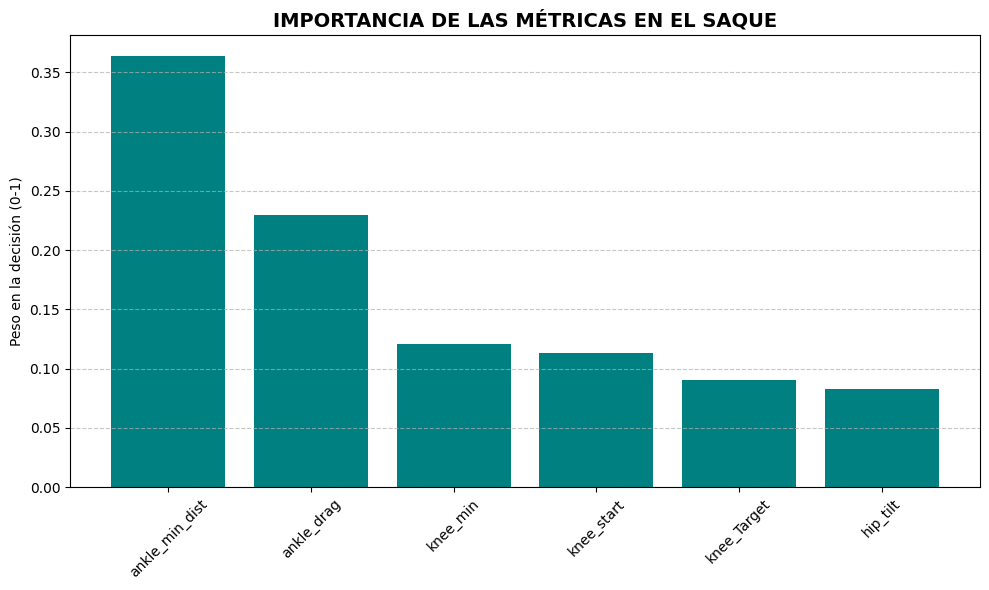

Métrica: ankle_min_dist -> Impacto: 36.36%
Métrica: ankle_drag -> Impacto: 22.95%
Métrica: knee_min -> Impacto: 12.09%
Métrica: knee_start -> Impacto: 11.31%
Métrica: knee_Target -> Impacto: 9.01%
Métrica: hip_tilt -> Impacto: 8.28%


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Extraemos el modelo Random Forest de tu diccionario o lo re-entrenamos rápido
rf_model = modelos["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

# Graficar
plt.figure(figsize=(10, 6))
plt.title("IMPORTANCIA DE LAS MÉTRICAS EN EL SAQUE", fontsize=14, fontweight='bold')
plt.bar(range(X.shape[1]), importances[indices], color='teal', align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.ylabel("Peso en la decisión (0-1)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Imprimir explicación para la memoria
for i in range(len(features)):
    print(f"Métrica: {features[indices[i]]} -> Impacto: {importances[indices[i]]*100:.2f}%")